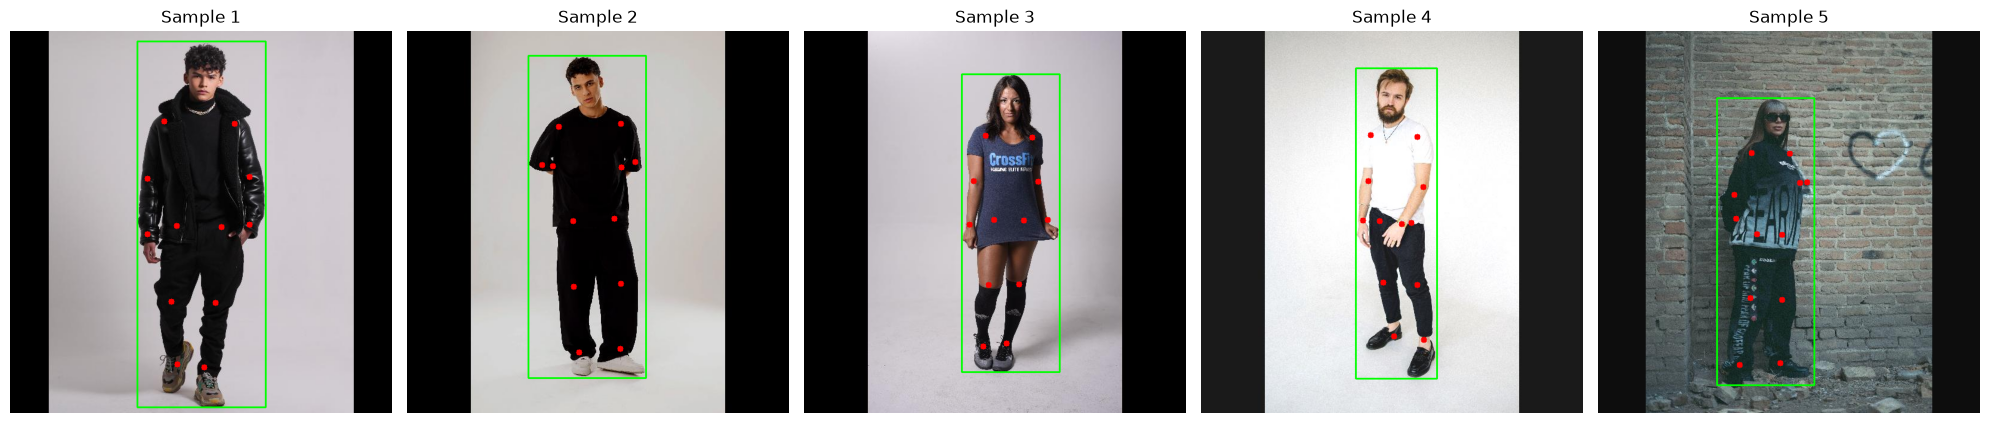

In [2]:
import cv2
import matplotlib.pyplot as plt
import os
import random

dataset_path = r'D:\Upgrade model Yolo11n-pose\ultralytics\KLYVERO_Dataset\KLYVERO-Pose.v1i.yolov11-pose\train' 
images_dir = os.path.join(dataset_path, 'images')
labels_dir = os.path.join(dataset_path, 'labels')

# سحب 5 صور عشوائياً من المجلد
image_files = random.sample([f for f in os.listdir(images_dir) if f.endswith(('.jpg', '.png'))], 5)

plt.figure(figsize=(20, 10))

for i, img_name in enumerate(image_files):
    # قراءة الصورة وتحويل ألوانها لتناسب Matplotlib
    img_path = os.path.join(images_dir, img_name)
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w, _ = img.shape

    # قراءة ملف الـ txt المقابل
    label_name = img_name.rsplit('.', 1)[0] + '.txt'
    label_path = os.path.join(labels_dir, label_name)

    if os.path.exists(label_path):
        with open(label_path, 'r') as f:
            lines = f.readlines()

        for line in lines:
            data = list(map(float, line.strip().split()))
            
            # 1. رسم الصندوق المحيط (Bounding Box)
            cx, cy, bw, bh = data[1:5]
            x1, y1 = int((cx - bw/2) * w), int((cy - bh/2) * h)
            x2, y2 = int((cx + bw/2) * w), int((cy + bh/2) * h)
            cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)

            # 2. رسم النقاط المفصلية الـ 12 (Keypoints)
            keypoints = data[5:]
            for j in range(0, len(keypoints), 3):
                kx = int(keypoints[j] * w)
                ky = int(keypoints[j+1] * h)
                visibility = keypoints[j+2] # 0: غير موجودة, 1: مخفية, 2: ظاهرة
                
                if visibility > 0:
                    cv2.circle(img, (kx, ky), 5, (255, 0, 0), -1)

    # عرض الصورة في الشبكة
    plt.subplot(1, 5, i+1)
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Sample {i+1}")

plt.tight_layout()
plt.show()